### SAR comparison between TA, ISO and TSV

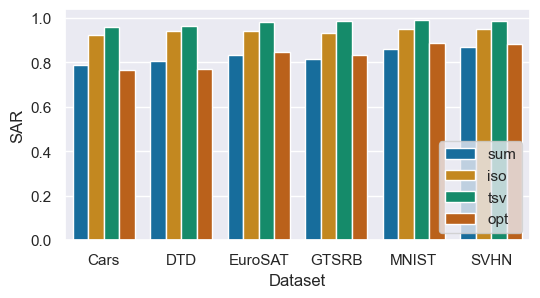

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme()
sns.set_palette("colorblind")

sar = { 
    "sum": {"Cars": 0.78620523, "DTD": 0.8081219, "EuroSAT": 0.8315229, "GTSRB": 0.816833, "MNIST": 0.8613162, "SVHN": 0.8681785}, 
    "iso":  {"Cars": 0.92468745, "DTD": 0.9393305, "EuroSAT": 0.9413924, "GTSRB": 0.93364024, "MNIST": 0.9489486, "SVHN": 0.9522428},
    "tsv": {"Cars": 0.96024275, "DTD": 0.9621821, "EuroSAT": 0.98246443, "GTSRB": 0.9853669, "MNIST": 0.9894316, "SVHN": 0.9872684},
    "opt": {"Cars": 0.76577675, "DTD": 0.77216804, "EuroSAT": 0.84574395, "GTSRB": 0.83108664, "MNIST": 0.885977, "SVHN": 0.88347983}
}

data = [{'Dataset': ds, 'Method': m, 'SAR': v} for m, d in sar.items() for ds, v in d.items()]
df = pd.DataFrame(data)

plt.figure(figsize=(6, 3))
sns.barplot(data=df, x="Dataset", y="SAR", hue="Method")
plt.legend(loc='lower right')
plt.show()

tensor(5.2709) tensor(1.0587)
tensor(6.1192) tensor(0.4256)
tensor(5.9933) tensor(1.5201)
tensor(5.9125) tensor(0.0913)
tensor(4.7195) tensor(0.4297)
tensor(6.0542) tensor(2.2639)
tensor(4.7468) tensor(0.3520)
tensor(5.5609) tensor(0.9215)
tensor(7.4314) tensor(0.2314)
tensor(5.6359) tensor(0.4456)
tensor(6.0245) tensor(1.9500)
tensor(5.0966) tensor(0.6442)
tensor(5.9986) tensor(0.1084)
tensor(6.5982) tensor(2.4577)
tensor(5.1935) tensor(0.2552)
tensor(5.5440) tensor(0.5034)
tensor(5.9587) tensor(0.9236)
tensor(5.5376) tensor(1.4798)
tensor(6.3059) tensor(0.9763)
tensor(4.6896) tensor(0.1411)
tensor(4.5116) tensor(0.4721)
tensor(6.2434) tensor(0.4528)
tensor(4.9116) tensor(0.1153)
tensor(6.0953) tensor(0.2798)
tensor(5.7732) tensor(3.1300)
tensor(5.2568) tensor(0.1964)
tensor(6.2709) tensor(0.6104)
tensor(5.7030) tensor(0.6721)
tensor(5.4847) tensor(0.3631)
tensor(5.0311) tensor(0.2341)
tensor(5.5172) tensor(0.2894)
tensor(5.0810) tensor(0.0183)
tensor(6.0773) tensor(2.0950)
tensor(3.8

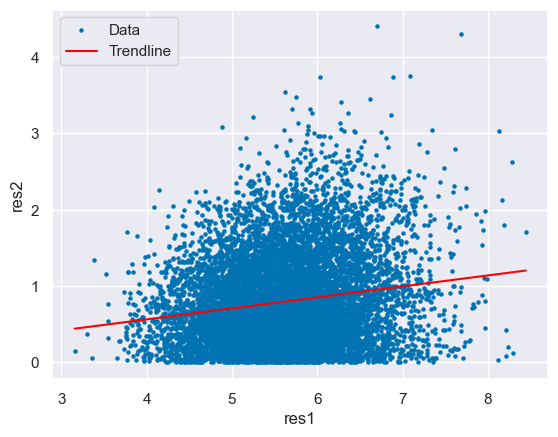

In [64]:
import torch
import numpy as np

res1s = []
res2s = []
for _ in range(10_000):
    u = torch.randn(32, 1)
    u = u / torch.linalg.norm(u)
    B = torch.randn(32, 32)
    res1 = torch.linalg.norm(u @ u.T @ B, ord='fro')
    res2 = torch.linalg.norm(u.T @ B @ u, ord='fro')
    if res1 < res2:
        print("Failed")
    print(res1, res2)
    res1s.append(res1)
    res2s.append(res2)

# plot x-axis res1s, y-axis res2s with trendline
plt.scatter(res1s, res2s, label='Data', s=5)  # made points smaller with s=5
plt.xlabel("res1")
plt.ylabel("res2")

# Compute and plot trendline
res1s_np = np.array(res1s)
res2s_np = np.array(res2s)
coeffs = np.polyfit(res1s_np, res2s_np, 1)
trendline = np.poly1d(coeffs)
plt.plot(
    sorted(res1s_np), 
    trendline(sorted(res1s_np)), 
    color='red', 
    label='Trendline'
)

plt.legend()
plt.show()


In [69]:
import torch
import numpy as np

res1s = []
res2s = []
for _ in range(10_000):
    x = torch.randn(32, 1)
    x = x / torch.linalg.norm(x)
    B = torch.randn(32, 32)
    u, s, vt = torch.linalg.svd(B)
    res1 = torch.linalg.norm(u[:, :1] @ u[:, :1].T @ B, ord='fro')
    res2 = torch.linalg.norm(x @ x.T @ B, ord='fro')
    if res1 < res2:
        print("Failed")
        exit()
    # print(res1, res2)
    # res1s.append(res1)
    # res2s.append(res2)
print("Success")


# # plot x-axis res1s, y-axis res2s with trendline
# plt.scatter(res1s, res2s, label='Data', s=5)  # made points smaller with s=5
# plt.xlabel("res1")
# plt.ylabel("res2")

# # Compute and plot trendline
# res1s_np = np.array(res1s)
# res2s_np = np.array(res2s)
# coeffs = np.polyfit(res1s_np, res2s_np, 1)
# trendline = np.poly1d(coeffs)
# plt.plot(
#     sorted(res1s_np), 
#     trendline(sorted(res1s_np)), 
#     color='red', 
#     label='Trendline'
# )

# plt.legend()
# plt.show()


Success


In [8]:
import torch
import numpy as np

def compute_batched_sar(u, delta_t):
    nums = torch.linalg.norm(torch.einsum("ij,jk,bkl", u, u.T, delta_t), ord='fro', dim=(1, 2))
    dens = torch.linalg.norm(delta_t, ord='fro', dim=(1, 2))
    return (nums / dens).mean()

def calc_rank(S, norm_thresh=0.95):
    # Rank based on approximation error (Eq. 6) in the paper
    rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)
    return rank

rank_threshold = 0.95
delta_t = torch.randn(10, 32, 32)
u_sum, s_sum, vt_sum = torch.linalg.svd(delta_t.sum(dim=0), full_matrices=False)

delta_t_outers = torch.einsum("bij,bjk->bik", delta_t, delta_t.permute(0, 2, 1))
delta_t_frobs = torch.linalg.norm(delta_t, ord='fro', dim=(1, 2)).square()[:, None, None]
mat_a = (delta_t_outers / delta_t_frobs).sum(dim=0)
u_opt, s_opt, vt_opt = torch.linalg.svd(mat_a, full_matrices=False)

sum_rel_rank = calc_rank(s_sum.cpu(), norm_thresh=rank_threshold)
opt_rel_rank = calc_rank(s_opt.cpu(), norm_thresh=rank_threshold)

u_sum_k = u_sum[:, :sum_rel_rank]
u_opt_k = u_opt[:, :opt_rel_rank]

# print(sum_rel_rank, opt_rel_rank)

res_sum = compute_batched_sar(u_sum_k, delta_t)
res_opt = compute_batched_sar(u_opt_k, delta_t)
print(res_sum, res_opt)


tensor(0.7156) tensor(0.9064)


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_28664/96167499.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)


### Layer-wise statistics

In [2]:
import sys
from pathlib import Path

# Allow importing the local `src` package
sys.path.append(str(Path.cwd().parent))


In [3]:
# Load model for Cars
import torch
import certifi
import os

os.environ['SSL_CERT_FILE'] = certifi.where()

from src.models.modeling import ImageClassifier, ImageEncoder
from src.models.heads import build_classification_head
from src.datasets.templates import get_templates

dataset_name = "CIFAR10"
batch_size = 32
template = get_templates(dataset_name)
data_location = "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ViT-B-16"

# Build model
image_encoder = ImageEncoder(model_name, keep_lang=True)

classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
model = ImageClassifier(image_encoder, classification_head)


/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Building classification head.


100%|██████████| 10/10 [00:01<00:00,  7.93it/s]

zeroshot shape, Ptorch.Size([10, 512])


In [5]:
from src.datasets.registry import get_dataset
from src.datasets.common import get_dataloader_v2, maybe_dictionarize

dataset_name = "CIFAR10"
batch_size = 32
dataset = get_dataset(
    dataset_name,
    model.val_preprocess,
    location=data_location,
    batch_size=batch_size,
)
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

In [6]:
# Pass single batch and measure mean and std of all activations
data = maybe_dictionarize(next(iter(dataloader)))
x = data['images']
out = model(x)
# >>> out.shape
# torch.Size([32, 1000])

In [8]:
import torch

stats = {}  # name -> [sum, sumsq, count, shape]

def hook(name):
    def h(_m, _i, o):
        if torch.is_tensor(o):
            x = o.detach().float()
            if name not in stats:
                stats[name] = [0.0, 0.0, 0, tuple(x.shape)]
            s, ss, n, sh = stats[name]
            stats[name][0] = s  + x.sum().item()
            stats[name][1] = ss + (x * x).sum().item()
            stats[name][2] = n  + x.numel()
    return h

with torch.no_grad():
    for i, batch in enumerate(dataloader):
        x = maybe_dictionarize(batch)["images"]
        model(x)
        print("Batch", i)
        if i > 10:
            break

: 

In [21]:
import torch

stats = {}

def stat(x):
    x = x.detach().float()
    return x.mean().item(), x.std(unbiased=False).item(), tuple(x.shape)

hooks = []

def hook(name):
    def h(_m, _i, o):
        if torch.is_tensor(o):
            stats[name] = stat(o)
    return h

enc = model.image_encoder  # or model.image_encoder.model.visual

for n, m in enc.named_modules():
    if isinstance(m, torch.nn.Linear):
        hooks.append(m.register_forward_hook(hook(n)))

x = maybe_dictionarize(next(iter(dataloader)))["images"]

with torch.no_grad():
    model(x)

for h in hooks:
    h.remove()

for k, (mu, sd, sh) in sorted(stats.items()):
    print(f"{k:40s} {sh}  μ={mu:.3g} σ={sd:.3g}")


model.visual.transformer.resblocks.0.mlp.c_fc (32, 197, 3072)  μ=-1.47 σ=1.9
model.visual.transformer.resblocks.0.mlp.c_proj (32, 197, 768)  μ=-0.00643 σ=0.118
model.visual.transformer.resblocks.1.mlp.c_fc (32, 197, 3072)  μ=-0.859 σ=0.851
model.visual.transformer.resblocks.1.mlp.c_proj (32, 197, 768)  μ=0.00434 σ=0.124
model.visual.transformer.resblocks.10.mlp.c_fc (32, 197, 3072)  μ=-3.03 σ=2.06
model.visual.transformer.resblocks.10.mlp.c_proj (32, 197, 768)  μ=-0.00165 σ=0.214
model.visual.transformer.resblocks.11.mlp.c_fc (32, 197, 3072)  μ=-0.842 σ=0.76
model.visual.transformer.resblocks.11.mlp.c_proj (32, 197, 768)  μ=-0.00699 σ=0.236
model.visual.transformer.resblocks.2.mlp.c_fc (32, 197, 3072)  μ=-0.667 σ=0.742
model.visual.transformer.resblocks.2.mlp.c_proj (32, 197, 768)  μ=-0.00219 σ=0.111
model.visual.transformer.resblocks.3.mlp.c_fc (32, 197, 3072)  μ=-0.599 σ=0.745
model.visual.transformer.resblocks.3.mlp.c_proj (32, 197, 768)  μ=-2.38e-05 σ=0.105
model.visual.transformer

In [22]:
stats

{'model.visual.transformer.resblocks.0.mlp.c_fc': (-1.4697901010513306,
  1.898494005203247,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.0.mlp.c_proj': (-0.006426222622394562,
  0.11794182658195496,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.1.mlp.c_fc': (-0.8588884472846985,
  0.8510082364082336,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.1.mlp.c_proj': (0.004336865618824959,
  0.12350844591856003,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.2.mlp.c_fc': (-0.6671441197395325,
  0.7421253323554993,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.2.mlp.c_proj': (-0.002186467871069908,
  0.11072870343923569,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.3.mlp.c_fc': (-0.5986319780349731,
  0.7449847459793091,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.3.mlp.c_proj': (-2.381700869591441e-05,
  0.1053268313407898,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.4.mlp.c_fc': (-0.7926779389381409,
  

In [ ]:
!pip install seaborn
!pip install matplotlib
!pip install pandas


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.2 MB/s  0:00:06m0:00:0100:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.2 MB/s  0:00:02 eta 0:00:01
Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m5/7 [matplotlib]


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_23209/508623562.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


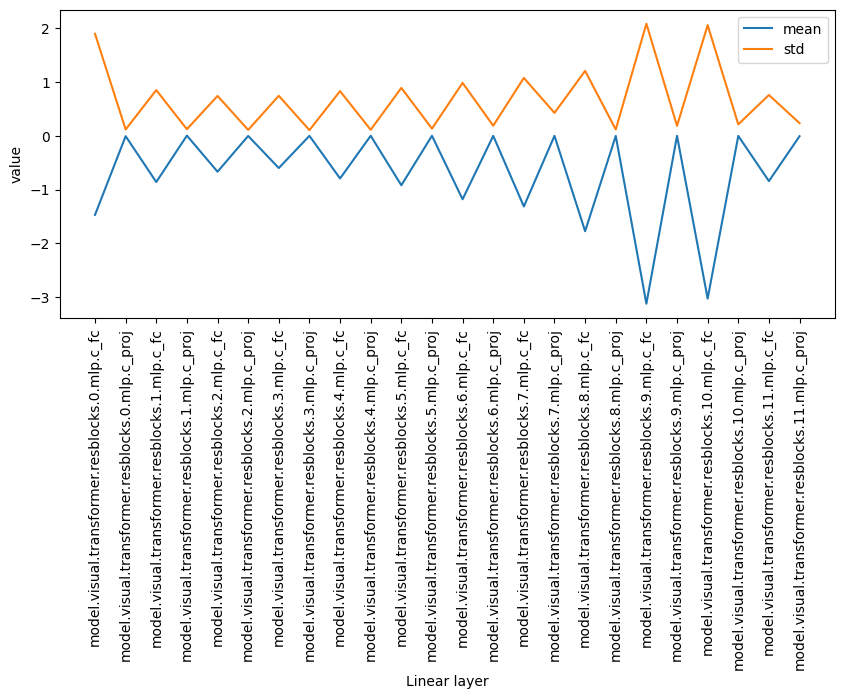

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

names = list(stats.keys())
means = [stats[k][0] for k in names]
stds  = [stats[k][1] for k in names]

plt.figure(figsize=(10, 4))
sns.lineplot(x=range(len(means)), y=means, label="mean")
sns.lineplot(x=range(len(stds)),  y=stds,  label="std")

plt.xticks(range(len(names)), names, rotation=90)
plt.ylabel("value")
plt.xlabel("Linear layer")
plt.tight_layout()
plt.show()
